In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
%cd "/content/drive/MyDrive/Taller de Complejidad/Perimetro A-B/"
%ls

ruta_salida = "/content/drive/MyDrive/Taller de Complejidad/Perimetro A-B/output/"

/content/drive/MyDrive/Taller de Complejidad/Perimetro A-B
 input/  'RNN LSTM'/  'RNN LSTMConv'/


In [4]:
#BASE C5
base = pd.read_csv("/content/drive/MyDrive/Taller de Complejidad/Perimetro A-B/input/incidencia_C5_periAB_2018_2023.csv")


In [8]:
print(f'La base cuenta con {len(base)} obervaciones de crimen y columnas\n {base.columns}')

La base cuenta con 169267 obervaciones de crimen y columnas
 Index(['Unnamed: 0', 'folio', 'tipo_entrada', 'codigo_cierre',
       'delegacion_inicio', 'sector_inicio', 'clas_con_f_alarma',
       'incidente_c4', 'fecha_creacion', 'fecha_cierre', 'hora_creacion',
       'hora_cierre', 'longitud', 'latitud', 'day', 'month', 'year', 'hora',
       'fecha_delito', 'month_char', 'dia_char', 'idpts', 'idpoli'],
      dtype='object')



# FILTRADO BASES

In [ ]:
#c5
base['clas_con_f_alarma'].unique()
#fiscalia
#base['categoria_delito'].unique()

array(['DELITO', 'EMERGENCIA', 'FALTA C?VICA', 'DELITO DE ALTO IMPACTO',
       'URGENCIAS MEDICAS', 'SERVICIO', 'FALTA CÍVICA', 'INFORMACIÓN',
       'FALSA ALARMA', 'PRUEBA', 'INCIDENTES EXTERNOS'], dtype=object)

# Clasificación con f de alarma

In [ ]:
#base.groupby('clas_con_f_alarma').size()
#base.groupby('clas_con_f_alarma').count()
base['clas_con_f_alarma'].value_counts().reset_index()

,clas_con_f_alarma,count
0,URGENCIAS MEDICAS,48678
1,SERVICIO,43397
2,DELITO,38977
3,FALTA CÍVICA,17516
4,EMERGENCIA,11675
5,DELITO DE ALTO IMPACTO,6065
6,FALTA C?VICA,2904
7,INFORMACIÓN,36
8,PRUEBA,9
9,INCIDENTES EXTERNOS,8


[]

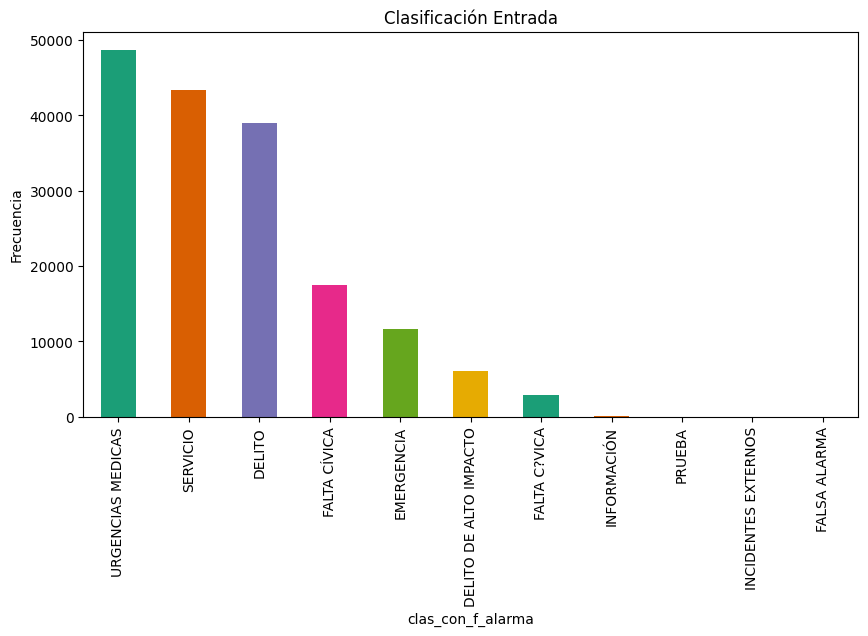

In [ ]:
fig, ax = plt.subplots(figsize=(10,5))
base['clas_con_f_alarma'].value_counts().plot(kind='bar', color=sns.palettes.mpl_palette('Dark2'))
plt.title("Clasificación Entrada",fontsize=12);
plt.xlabel('clas_con_f_alarma', fontsize=10);plt.ylabel('Frecuencia', fontsize=10)
plt.plot()
#plt.savefig("./imagenes/conteo_alcaldia_inicio.png", dpi=600)

# TIPO ENTRADA

In [ ]:
#base.groupby('tipo_entrada').size()
base['tipo_entrada'].value_counts().reset_index()

,tipo_entrada,count
0,LLAMADA DEL 911,124414
1,RADIO,41856
2,APLICATIVOS,1639
3,REDES,561
4,LLAMADA APP911,508
5,ZELLO,139
6,SOS MUJERES *765,106
7,LECTOR DE PLACAS,38
8,MI CIUDAD,6


[]

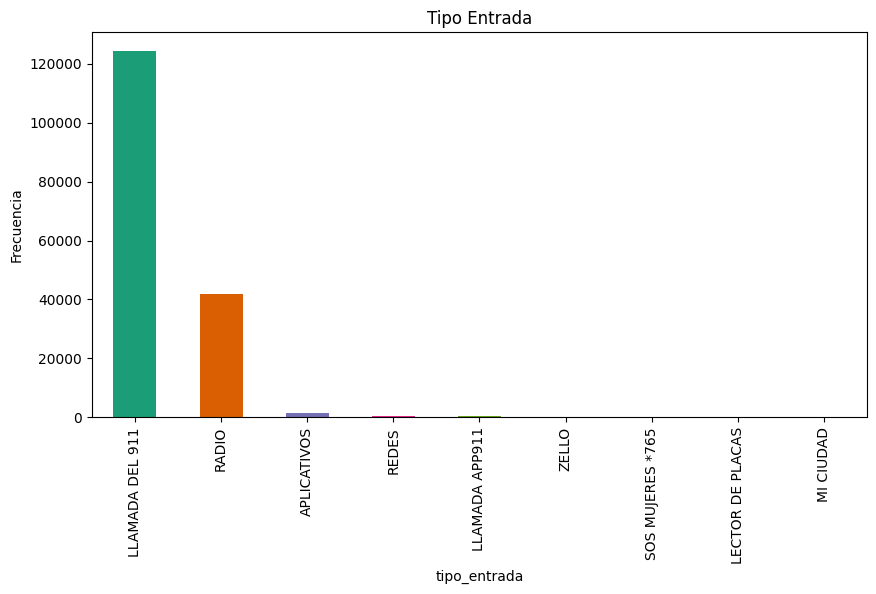

In [ ]:
fig, ax = plt.subplots(figsize=(10,5))
base['tipo_entrada'].value_counts().plot(kind='bar', color=sns.palettes.mpl_palette('Dark2'))
plt.title("Tipo Entrada",fontsize=12);
plt.xlabel('tipo_entrada', fontsize=10);plt.ylabel('Frecuencia', fontsize=10)
plt.plot()
#plt.savefig("./imagenes/conteo_alcaldia_inicio.png", dpi=600)

# FILTRADO DE LA BASE

In [ ]:
base[base['clas_con_f_alarma'].isin(["HOMICIDIO DOLOSO POR ARMA DE FUEGO"])]

,Unnamed: 0,folio,tipo_entrada,codigo_cierre,delegacion_inicio,sector_inicio,clas_con_f_alarma,incidente_c4,fecha_creacion,fecha_cierre,...,latitud,day,month,year,hora,fecha_delito,month_char,dia_char,idpts,idpoli


In [ ]:
#base.columns
base.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169267 entries, 0 to 169266
Data columns (total 23 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         169267 non-null  int64  
 1   folio              169267 non-null  object 
 2   tipo_entrada       169267 non-null  object 
 3   codigo_cierre      169267 non-null  object 
 4   delegacion_inicio  169266 non-null  object 
 5   sector_inicio      169267 non-null  object 
 6   clas_con_f_alarma  169267 non-null  object 
 7   incidente_c4       169267 non-null  object 
 8   fecha_creacion     169267 non-null  object 
 9   fecha_cierre       169267 non-null  object 
 10  hora_creacion      169267 non-null  object 
 11  hora_cierre        169267 non-null  object 
 12  longitud           169267 non-null  float64
 13  latitud            169267 non-null  float64
 14  day                169267 non-null  int64  
 15  month              169267 non-null  int64  
 16  ye

In [ ]:
base.columns

Index(['Unnamed: 0', 'folio', 'tipo_entrada', 'codigo_cierre',
       'delegacion_inicio', 'sector_inicio', 'clas_con_f_alarma',
       'incidente_c4', 'fecha_creacion', 'fecha_cierre', 'hora_creacion',
       'hora_cierre', 'longitud', 'latitud', 'day', 'month', 'year', 'hora',
       'fecha_delito', 'month_char', 'dia_char', 'idpts', 'idpoli'],
      dtype='object')

# Analisis de Series de Tiempo

In [ ]:
#columna c5 'fecha_creacion', fiscalia: fecha_inicio  notas: standard_date

base['fecha_delito'] = pd.to_datetime(base['fecha_cierre'], format='%Y-%m-%d', errors='coerce')

# Crear las nuevas columnas para mes, año, día y sus versiones en texto
base['month'] = base['fecha_delito'].dt.month                      # Mes como número (ej: 1 para enero)
base['month_char'] = base['fecha_delito'].dt.month_name()          # Mes como texto (ej: "January")
base['year'] = base['fecha_delito'].dt.year                        # Año (ej: 2024)
base['day'] = base['fecha_delito'].dt.day                          # Día como número (ej: 15)
base['dia_char'] = base['fecha_delito'].dt.day_name()              # Día como texto (ej: "Monday")

# Para nombres de meses y días en español (si necesario):
base['month_char'] = base['fecha_delito'].dt.strftime('%B')        # Mes como texto en español (ej: "enero")
base['dia_char'] = base['fecha_delito'].dt.strftime('%A')          # Día como texto en español (ej: "lunes")


In [ ]:
#base.tail(13872)
base.tail().sort_values('fecha_creacion',ascending=True)

,Unnamed: 0,folio,tipo_entrada,codigo_cierre,delegacion_inicio,sector_inicio,clas_con_f_alarma,incidente_c4,fecha_creacion,fecha_cierre,...,latitud,day,month,year,hora,fecha_delito,month_char,dia_char,idpts,idpoli
169262,169263,C5/20231231/02295,LLAMADA DEL 911,A,CUAUHTEMOC,ALAMEDA,URGENCIAS MEDICAS,Lesionado-Por Golpes-Agresión,2023-12-31,2023-12-31,...,19.434989,31,12,2023,14,2023-12-31,December,Sunday,169263,557
169263,169264,C5/20231231/02990,LLAMADA DEL 911,A,CUAUHTEMOC,ALAMEDA,DELITO,Denuncia-Fraude,2023-12-31,2023-12-31,...,19.427940,31,12,2023,17,2023-12-31,December,Sunday,169264,634
169264,169265,C5/20231231/03015,LLAMADA DEL 911,A,CUAUHTEMOC,BUENAVISTA,DELITO,Disturbio-Quema de Pirotecnia,2023-12-31,2023-12-31,...,19.444916,31,12,2023,17,2023-12-31,December,Sunday,169265,484
169265,169266,C5/20231231/03501,LLAMADA DEL 911,A,CUAUHTEMOC,C5,DELITO,Agresión-Violencia Intrafamiliar,2023-12-31,2023-12-31,...,19.438042,31,12,2023,18,2023-12-31,December,Sunday,169266,516
169266,169267,C5/20231231/04002,LLAMADA DEL 911,A,CUAUHTEMOC,CENTRO,DELITO,Disturbio-Quema de Pirotecnia,2023-12-31,2023-12-31,...,19.427636,31,12,2023,20,2023-12-31,December,Sunday,169267,273


## Creamos la serie de tiempo

In [ ]:
#filtramos las fechas mayores a 2018
base = base[base['fecha_delito']>='2018-01-01']
f"Filas y columnas del dataframe {base.shape}"

'Filas y columnas del dataframe (169267, 23)'

In [ ]:
#conteo de observacione spor año
base['year'].value_counts().sort_values()

,count
year,
2018,9633
2019,9897
2020,32121
2021,37275
2023,38334
2022,42007


# Creamos la serie de tiempo: Agrupar por dia y mes

In [ ]:
# Agrupar los datos por fecha y contar el número de delitos por dia
serie_tiempo = base.groupby(base['fecha_delito'].dt.to_period('D')).size()
#serie_tiempo = base.groupby(base['fecha_delito'].dt.to_period('M')).size()
print(len(serie_tiempo))

2162


In [ ]:
serie_tiempo.head() # primer dia se presentaron 31 delitos

,0
fecha_delito,
2018-01-03,31
2018-01-04,18
2018-01-05,31
2018-01-06,25
2018-01-07,27


In [ ]:
serie_tiempo.tail() #ultimo dia se presentaron 98 delitos con fecha 2023-12-31

,0
fecha_delito,
2023-12-27,97
2023-12-28,83
2023-12-29,109
2023-12-30,103
2023-12-31,98


In [ ]:
# Convertir la serie a un dataframe para facilidad de uso
serie_tiempo = serie_tiempo.reset_index(name='num_delitos')
serie_tiempo['fecha_delito'] = serie_tiempo['fecha_delito'].dt.to_timestamp()

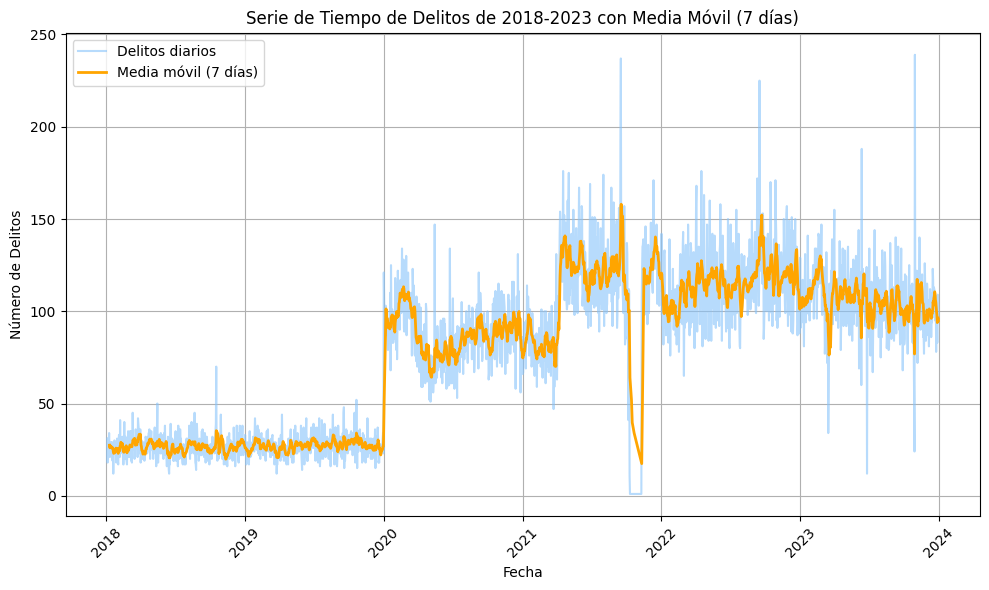

In [ ]:
# Graficar la serie de tiempo original y la curva suavizada
plt.figure(figsize=(10, 6))

plt.plot(serie_tiempo['fecha_delito'], serie_tiempo['num_delitos'], label='Delitos diarios',color='#87C3FA',alpha=0.6)
# Calcular la media móvil de 7 días
serie_tiempo['media_movil_7d'] = serie_tiempo['num_delitos'].rolling(window=7).mean()
plt.plot(serie_tiempo['fecha_delito'], serie_tiempo['media_movil_7d'], label='Media móvil (7 días)', color='orange', linewidth=2)
# Configuraciones del gráfico
plt.title('Serie de Tiempo de Delitos de 2018-2023 con Media Móvil (7 días)')
plt.xlabel('Fecha')
plt.ylabel('Número de Delitos')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

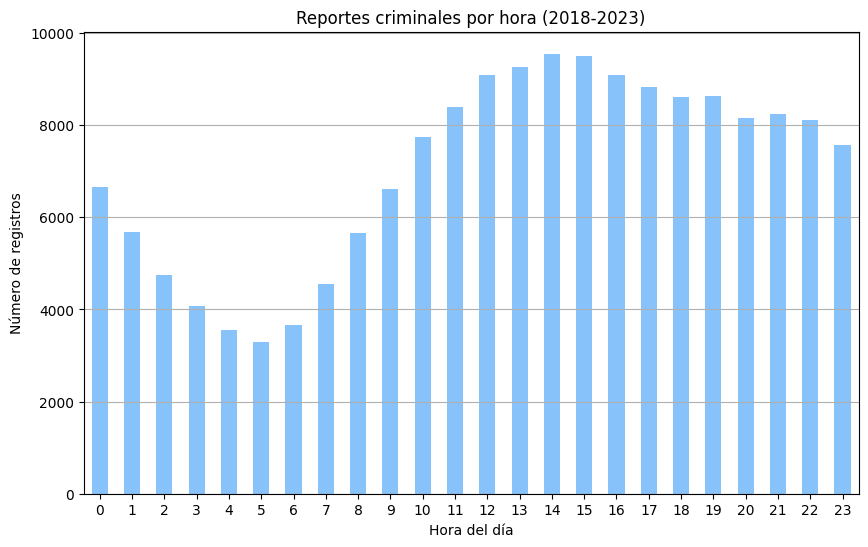

In [ ]:
# Agrupar por hora y contar el número de registros por cada hora
hourly_counts = base.groupby('hora').size()

# Graficar
plt.figure(figsize=(10, 6))
#hourly_counts.plot(kind='bar', color='orange')
hourly_counts.plot(kind='bar', color='#87C3FA')
plt.title('Reportes criminales por hora (2018-2023)')
plt.xlabel('Hora del día')
plt.ylabel('Número de registros')
plt.xticks(rotation=0)
plt.grid(axis='y')

# Mostrar la gráfica
plt.show()
#plt.savefig("./imagenes/reportes_crimen_por_hora.jpg", dpi=600)

In [ ]:
#serie_tiempo = serie_tiempo[serie_tiempo['fecha_delito']>="2019-01-01"]

In [ ]:
serie_tiempo.head()   # primer dia se presentaron 20 delitos con fecha 2018-01-02
#serie_tiempo2=serie_tiempo

serie_tiempo.to_csv(f"{ruta_salida}/RED_LSTM_serie_tiempo_C5_mensual AB.csv", index=False)

In [ ]:
serie_tiempo_copi = serie_tiempo
serie_tiempo.head()



,fecha_delito,num_delitos
0,2018-01-03,31
1,2018-01-04,18
2,2018-01-05,31
3,2018-01-06,25
4,2018-01-07,27


# Análisis de Series de Tiempo con TENSORFLOW

In [ ]:
import tensorflow as tf
from tensorflow import keras

In [ ]:
# Convertir la columna 'fecha_delito' a un formato numérico (timestamp en segundos)
serie_tiempo['fecha_delito_num'] = serie_tiempo['fecha_delito'].view(np.int64) // 10**9  # Conversion a segundos

# Verifica el tipo de datos
serie_tiempo.head()

<ipython-input-31-3953316cc016>:2: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  serie_tiempo['fecha_delito_num'] = serie_tiempo['fecha_delito'].view(np.int64) // 10**9  # Conversion a segundos


,fecha_delito,num_delitos,fecha_delito_num
0,2018-01-03,31,1514937600
1,2018-01-04,18,1515024000
2,2018-01-05,31,1515110400
3,2018-01-06,25,1515196800
4,2018-01-07,27,1515283200


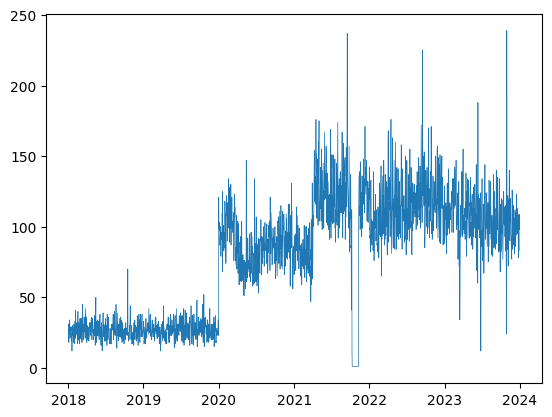

In [ ]:
plt.plot(serie_tiempo['fecha_delito'],serie_tiempo['num_delitos'],linewidth=0.5)

El error:

*ValueError: Failed to convert a NumPy array to a Tensor (Unsupported object type Timestamp)*

 Ocurre porque TensorFlow (o Keras) no acepta objetos del tipo Timestamp en las entradas del modelo. Los tensores necesitan ser convertidos a un formato numérico, como float, int, o array


In [ ]:
#estandarizamos los datos
#https://keepcoding.io/blog/metodos-de-normalizacion-en-python/

In [ ]:
# Normalización Z-score
from sklearn.preprocessing import StandardScaler
scaler_zscore = StandardScaler()
# Estandarizamos el numero de delitos
serie_tiempo['num_delitos'] = scaler_zscore.fit_transform(serie_tiempo[['num_delitos']])
#standarizacion 2
#serie_tiempo['num_delitos'] = (serie_tiempo['num_delitos']-serie_tiempo['num_delitos'].mean())/serie_tiempo['num_delitos'].std()

In [ ]:
serie_tiempo.head()

,num_delitos
0,-1.127959
1,-1.438023
2,-1.127959
3,-1.271066
4,-1.223364


In [ ]:
#método para convertir el DataFrame en el array NumPy
#serie_tiempo = serie_tiempo.to_numpy()
#método para convertir el DataFrame en el array de registros NumPy
#serie_tiempo = serie_tiempo.to_records()

#eliminamos la columna con la fecha timesstamp (datetime64[ns])
serie_tiempo.drop(columns=['fecha_delito',], inplace=True)
serie_tiempo.drop(columns=['fecha_delito_num',], inplace=True)


# Definir los conjuntos de entrenamiento (80%) y prueba (20%)

## Longitud de la serie de tiempo 2163
## Tamaño conjunto de entrenamiento 1730
## Tamaño conjunto de prueba 433

In [ ]:
#Tamaño conjunto de entrenamiento
train_size=int(len(serie_tiempo) * 0.8)
#Tamaño conjunto de prueba
test_size=len(serie_tiempo)-train_size
#Identificia las filas de acuerdo a los tamaños anterirores
train , test = serie_tiempo.iloc[:train_size], serie_tiempo .iloc[train_size:]
print(f"Longitud de la serie de tiempo {len(serie_tiempo)}")
print(f'Tamaño conjunto de entrenamiento {train_size} ')
print(f"Tamaño conjunto de prueba {test_size}")

Longitud de la serie de tiempo 2162
Tamaño conjunto de entrenamiento 1729 
Tamaño conjunto de prueba 433


In [ ]:
test.head(3)

,num_delitos
1729,0.613166
1730,0.803974
1731,1.376398


### Definimos la funcion que prepara el conjunto de datos

In [ ]:
#X es el dataFrame e y la columna del dataframe que voy a utlizar, time_steps es el tamaño de la ventana (número de neuronas de entrada)
def create_dataset(X,y,time_steps=1):
  Xs,ys=[],[]
  for i in range(len(X) - time_steps):
    v=X.iloc[i:i + time_steps].values
    Xs.append(v)
    ys.append(y.iloc[i + time_steps]) #Sólo una nuerona de salida
  return np.array(Xs),np.array(ys)

## Vamos a utliza una RED LSTM (**Long Short Term Memory**) o red de memoria a corto plazo, que es la usual para predicciones de series de tiempo y el optimizador de ADAM

**keras.Sequential()**: Este método inicializa un modelo secuencial. Un modelo secuencial es una pila lineal de capas, donde cada capa tiene exactamente una entrada y una salida. Es el tipo más simple de red neuronal donde cada capa se conecta directamente a la siguiente.

**model.add()**: Este método añade una capa a la red secuencial. Aquí se añade una capa LSTM (Long Short-Term Memory).

**keras.layers.LSTM(6)**: Esta es una capa LSTM que incluye 6 unidades o neuronas. Las capas LSTM son un tipo de red neuronal recurrente (RNN) que son efectivas para trabajar con secuencias de datos, como series de tiempo, datos secuenciales, etc. LSTM es útil para recordar dependencias a largo plazo en los datos.

- input_shape=(X_train.shape[1], X_train.shape[2]): Define la forma de la entrada a la red. Aquí, X_train.shape[1] es el número de timesteps en cada secuencia, y X_train.shape[2] es el número de características por timestep. Esta es la entrada esperada por la capa LSTM. Como es la primera capa, es necesario especificar la forma de entrada.

**keras.layers.Dense(1)**: Añade una capa densa o "fully connected" con una sola neurona de salida. Esta capa conecta todas las neuronas de la capa anterior con la salida. Al tener solo una neurona de salida, es común en problemas de regresión, donde se busca predecir un solo valor continuo.

**model.compile()**: Compila el modelo y lo prepara para su entrenamiento. Aquí se definen dos aspectos clave: la función de pérdida (loss) y el optimizador.

- *loss="mse"*: "mse" es la función de pérdida a utilizar, que significa Error Cuadrático Medio (Mean Squared Error). Es común en problemas de regresión, ya que mide la diferencia entre los valores predichos y los valores reales, tomando el promedio de los cuadrados de esas diferencias. Al ser una función de pérdida, su objetivo es minimizar este error durante el entrenamiento del modelo.

- *optimizer=keras.optimizers.Adam(0.01)*: Especifica el optimizador que se usará para ajustar los pesos del modelo. Adam es un algoritmo de optimización basado en el gradiente descendente estocástico, que es eficiente y popular para entrenar redes neuronales. El valor 0.01 es la tasa de aprendizaje (learning rate), que controla qué tan grandes son los ajustes que realiza el optimizador en cada iteración. Una tasa de aprendizaje más alta puede acelerar el entrenamiento, pero si es muy alta puede hacer que el modelo no converja adecuadamente.

In [ ]:
#time_steps=12 #Neuronas de entrada
time_steps=12 #Neuronas de entrada
X_train,y_train = create_dataset(X=train,y=train['num_delitos'],time_steps=time_steps)
X_test, y_test = create_dataset(X=test,y=test['num_delitos'],time_steps=time_steps)

# Parametros base C5

In [ ]:
#Declaramos una red multicapa de tal forma que cada que declaramos una capa se una con la capa anterior
model=keras.Sequential()
#la primera capa oculta, con 6 neuronas
model.add(keras.layers.LSTM(50,input_shape=(X_train.shape[1],X_train.shape[2]),activation='sigmoid'))
#Sólo pongo una neurona de salida
model.add(keras.layers.Dense(1))
#Adam es un el algoritmo de gradiente descendiente estocástico
model.compile(loss="mse",optimizer=keras.optimizers.Adam(0.1))

# Parámetros del modelo
#epochs = 2
#bs= 4   #aumentar al batch_size antes de epochs
#vs = 0.05
epochs = 50
bs= 16   #aumentar al batch_size antes de epochs
vs = 0.05


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# Parámetros notas

In [ ]:
#Declaramos una red multicapa de tal forma que cada que declaramos una capa se una con la capa anterior
model=keras.Sequential()
#la primera capa oculta, con 6 neuronas
model.add(keras.layers.LSTM(6,input_shape=(X_train.shape[1],X_train.shape[2]),activation='sigmoid'))
#Sólo pongo una neurona de salida
model.add(keras.layers.Dense(1))
#Adam es un el algoritmo de gradiente descendiente estocástico
model.compile(loss="mse",optimizer=keras.optimizers.Adam(0.1))

# Parámetros del modelo
epochs = 30
bs= 8  #aumentar al batch_size antes de epochs
vs = 0.01



# Entrenamiento

### Parámetros del `model.fit()`:

1. **X_train** y **y_train**:
   - Son los conjuntos de datos de entrada y salida que usas para entrenar tu modelo. `X_train` contiene las características (input) y `y_train` las etiquetas (output o target). Ambos deben estar correctamente formateados, y en el caso de LSTM, tener dimensiones 3D.

2. **epochs=30**:
   - **Definición**: El número de veces que el modelo verá todo el conjunto de entrenamiento. Una época implica que el modelo ha pasado por todas las muestras de entrenamiento una vez.
   - **Ajuste**: Si el número de épocas es bajo, el modelo puede no aprender lo suficiente (underfitting). Si es demasiado alto, puede sobreajustarse (overfitting), es decir, ajustarse demasiado a los datos de entrenamiento y no generalizar bien. Usualmente se comienza con un valor moderado, como 30, y se ajusta dependiendo del rendimiento.

3. **batch_size=3**:
   - **Definición**: El tamaño del lote que se usa para actualizar los pesos del modelo después de cada pasada. Es decir, cuántas muestras se procesan antes de realizar un ajuste a los pesos del modelo.
   - **Ajuste**: Un valor bajo (como 3) puede hacer que el entrenamiento sea más preciso, pero lento, ya que ajusta los pesos con más frecuencia. Un valor más grande puede acelerar el entrenamiento, pero puede ser menos preciso. Se puede experimentar con valores como 16, 32 o 64 dependiendo de la cantidad de datos y memoria disponible.

4. **validation_split=0.1**:
   - **Definición**: Es el porcentaje de los datos de entrenamiento que se usará como datos de validación para evaluar el rendimiento del modelo durante el entrenamiento. En este caso, el 10% de los datos de `X_train` y `y_train` se utilizarán para validación.
   - **Ajuste**: Puedes modificar este valor según la cantidad de datos. Si tienes pocos datos, puedes reducir este valor (por ejemplo, a 0.05). Si tienes muchos datos, puedes aumentarlo a 0.2 o 0.3.

5. **verbose=1**:
   - **Definición**: Controla el nivel de salida durante el entrenamiento. Si es 1, mostrará el progreso en cada época. Si es 2, mostrará solo un resumen después de cada época. Si es 0, no mostrará nada.
   - **Ajuste**: Puedes cambiarlo a 2 para reducir la cantidad de información mostrada o a 0 si no quieres ver ningún detalle del entrenamiento.

6. **shuffle=True**:
   - **Definición**: Indica si los datos deben ser mezclados (aleatorizados) antes de cada época.
   - **Ajuste**: Es recomendable mantener `shuffle=True` ya que esto ayuda a prevenir que el modelo memorice el orden de los datos, lo cual puede mejorar la capacidad de generalización. Si los datos tienen algún tipo de secuencia temporal que no quieres romper, podrías usar `shuffle=False`.

### Cómo mejorar la predicción de tu modelo:

- **epochs**: Puedes usar una estrategia como el *early stopping*, donde monitoreas la métrica de validación y detienes el entrenamiento si no mejora después de ciertas épocas. Esto previene el sobreajuste. Comienza con 30 o 50 y ajusta según los resultados.
  
- **batch_size**: Si tienes suficiente memoria, incrementarlo a 16 o 32 puede acelerar el entrenamiento pero perderá precisión. Experimenta para ver qué valor da mejores resultados.

- **learning rate del optimizador Adam**: Actualmente, lo tienes en 0.01. Un valor alto de *learning rate* puede hacer que el modelo converja más rápido pero también puede perderse en una solución subóptima. Prueba valores más pequeños como 0.001 o 0.0001.

- **validation_split**: Si tienes muchos datos, podrías incrementar el tamaño del conjunto de validación a 0.2 o 0.3 para obtener una mejor idea de cómo generaliza el modelo.

- **Regularización**: Puedes probar añadiendo regularización (como dropout o l2) para prevenir el sobreajuste si estás viendo que el modelo se ajusta demasiado a los datos de entrenamiento.


In [ ]:
from numpy.random.mtrand import shuffle
#Hacemos el ajuste (fit) de los pesos
history=model.fit(X_train,y_train,epochs = epochs,batch_size = bs,validation_split= vs,verbose=1,shuffle=True
)

Epoch 1/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 2.5621 - val_loss: 0.2311
Epoch 2/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1299 - val_loss: 0.2372
Epoch 3/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1392 - val_loss: 0.2554
Epoch 4/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1382 - val_loss: 0.2245
Epoch 5/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1610 - val_loss: 0.2177
Epoch 6/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1225 - val_loss: 0.2281
Epoch 7/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1240 - val_loss: 0.3267
Epoch 8/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1349 - val_loss: 0.2142
Epoch 9/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1249 - val_loss: 0.2694
Epoch 10/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1365 - val_loss: 0.2674
Epoch 11/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1184 - val_loss: 0.2533
Epoch 12/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms

[]

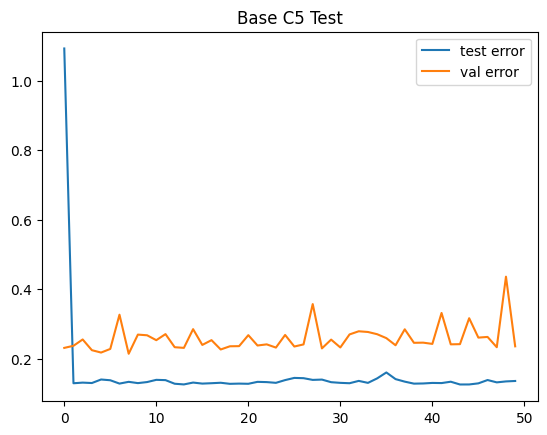

In [ ]:
plt.plot(history.history["loss"], label = "test error")
plt.plot(history.history["val_loss"], label = "val error")
#plt.savefig("/imagenes/LSTM_sigmoid_1hidden_{epochs}_{bs}_{vs}_val_error.png", dpi=600)
plt.title("Base C5 Test")
#plt.savefig(f"/content/drive/MyDrive/Taller de Complejidad/model_red_LSTM/imagenes/LSTM_fiscalia_test_error_{epochs}_{bs}_{vs}_prediccion.png", dpi=300)
#plt.savefig(f"/content/drive/MyDrive/Taller de Complejidad/model_red_LSTM/imagenes/LSTM_C5_test_error_{epochs}_{bs}_{vs}_prediccion.png", dpi=300)
#plt.savefig(f"/content/drive/MyDrive/Taller de Complejidad/model_red_LSTM/imagenes/LSTM_PERIODISTICAS_test_error_{epochs}_{bs}_{vs}_prediccion.png", dpi=300)
plt.legend()
plt.plot()

# Resultados del entrenamiento

In [ ]:
y_pred=model.predict(X_test)
#y_pred

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


[]

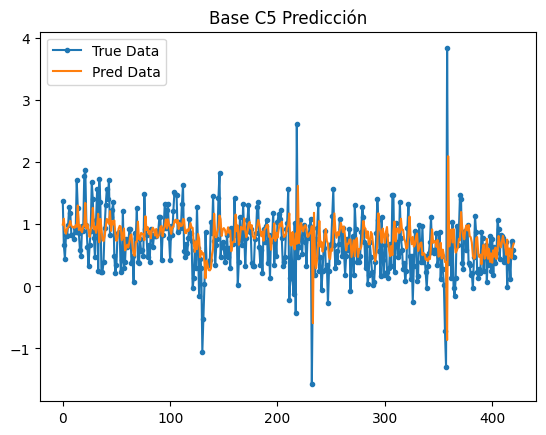

In [ ]:
plt.plot(y_test,marker=".",label = "True Data")
plt.plot(y_pred,label="Pred Data")
plt.title("Base C5 Predicción")
plt.legend()
plt.plot()
#plt.savefig(f"/content/drive/MyDrive/Taller de Complejidad/model_red_LSTM/imagenes/LSTM_ficalia_prediccion_{epochs}_{bs}_{vs}_prediccion.png", dpi=600)
#plt.savefig(f"/content/drive/MyDrive/Taller de Complejidad/model_red_LSTM/imagenes/LSTM_C5_prediccion_{epochs}_{bs}_{vs}_prediccion.png", dpi=300)


# <font color="#00FFFF">Predicciones</font>


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━

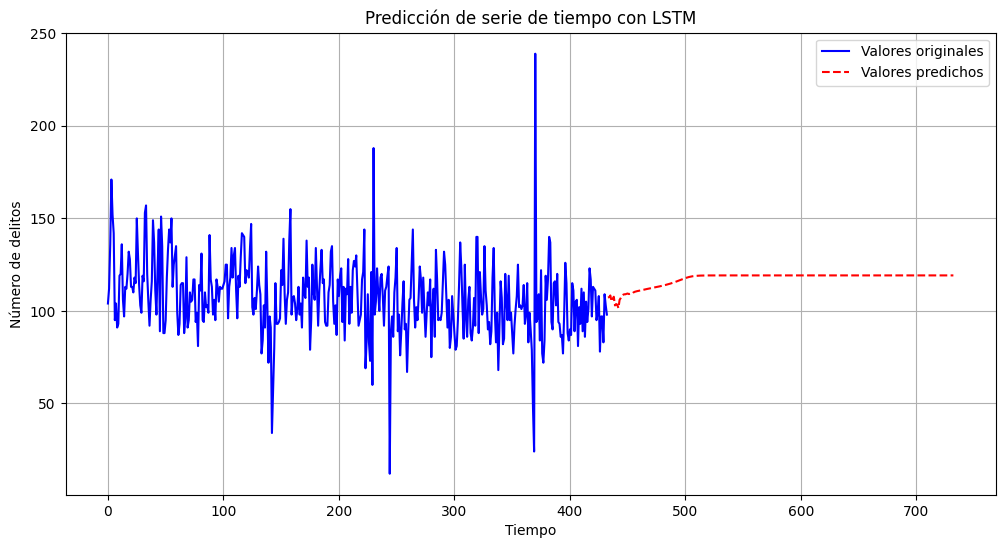

In [ ]:
# Crear una copia del escalador original para desnormalizar
scaler_inverse = scaler_zscore

# Función para predecir valores futuros
def predict_future_values(model, X_last, time_steps, future_steps):
    future_predictions = []
    input_seq = X_last[-time_steps:]

    for _ in range(future_steps):
        # Predecir el próximo valor
        pred = model.predict(input_seq[np.newaxis, :, :])[0, 0]
        future_predictions.append(pred)

        # Actualizar la secuencia de entrada con el nuevo valor
        new_seq = np.append(input_seq[1:], [[pred]], axis=0)
        input_seq = new_seq

    return np.array(future_predictions)

# Predecir los próximos 300 valores
time_steps = 12
future_steps = 300
X_last = X_test[-1]  # Última ventana del conjunto de prueba
future_values = predict_future_values(model, X_last, time_steps, future_steps)

# Desnormalizar los valores originales y predichos
original_values = scaler_inverse.inverse_transform(test['num_delitos'].values.reshape(-1, 1)).flatten()
predicted_future_values = scaler_inverse.inverse_transform(future_values.reshape(-1, 1)).flatten() #solo son los valores sin fechas

# Crear una serie de tiempo extendida para la gráfica
extended_series = np.concatenate([original_values, predicted_future_values])

# Gráfica de los resultados
plt.figure(figsize=(12, 6))
plt.plot(range(len(original_values)), original_values, label="Valores originales", color="blue")
plt.plot(range(len(original_values), len(extended_series)), predicted_future_values, label="Valores predichos", color="red", linestyle="--")
plt.title("Predicción de serie de tiempo con LSTM")
plt.xlabel("Tiempo")
plt.ylabel("Número de delitos")
plt.legend()
plt.grid()
plt.show()
#plt.savefig(f"/content/drive/MyDrive/Taller de Complejidad/model_red_LSTM/imagenes/LSTM_C5_prediccion_prediccion.png", dpi=600)

# <font color="#00FFFF">Las predicciones generadas con el modelo anterior no fueron buenas por lo tanto en la siguiente celda ajustaremos los parámetros de predicción del modelo para mejorar las predicciones</font>

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━

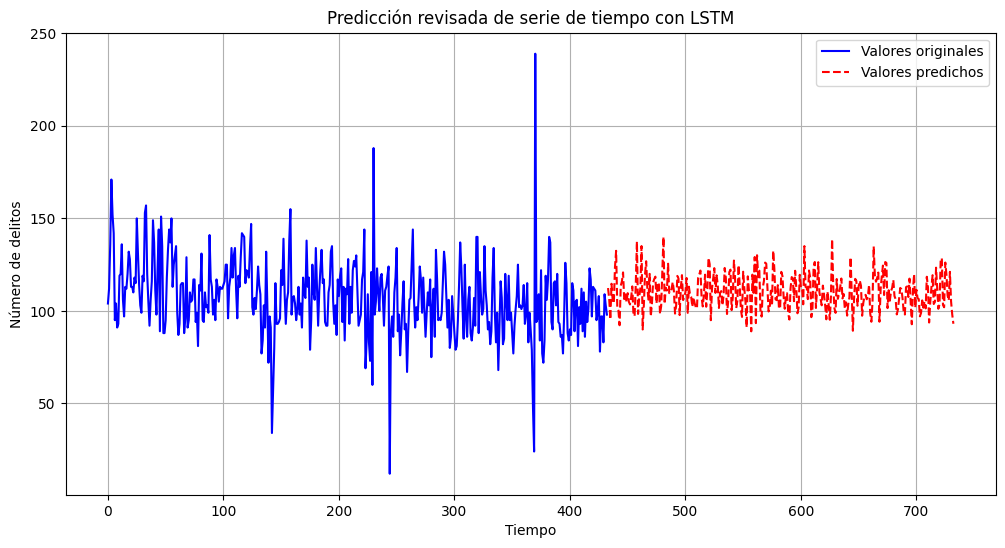

In [ ]:
# Ajustes al modelo

# Crear el modelo con una capa LSTM adicional
model = keras.Sequential()
model.add(keras.layers.LSTM(60, return_sequences=True, input_shape=(time_steps, X_train.shape[2]), activation='tanh'))
model.add(keras.layers.LSTM(60, activation='tanh'))  # Nueva capa LSTM
model.add(keras.layers.Dense(1))  # Capa de salida
model.compile(loss="mse", optimizer=keras.optimizers.Adam(0.01))

# Entrenar el modelo con más épocas y mayor batch_size
epochs = 170
batch_size = 80
vs=0.01
history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=vs, verbose=0)

# Predicción de valores futuros
time_steps = 48  # Aumentar tamaño de la ventana 24 a 48
future_steps = 300
X_last = X_test[-1]  # Última ventana
future_values = predict_future_values(model, X_last, time_steps, future_steps)

# Desnormalización
predicted_future_values = scaler_inverse.inverse_transform(future_values.reshape(-1, 1)).flatten()

# Gráfica revisada
plt.figure(figsize=(12, 6))
plt.plot(range(len(original_values)), original_values, label="Valores originales", color="blue")
plt.plot(range(len(original_values), len(extended_series)), predicted_future_values, label="Valores predichos", color="red", linestyle="--")
plt.title("Predicción revisada de serie de tiempo con LSTM")
plt.xlabel("Tiempo")
plt.ylabel("Número de delitos")
plt.legend()
plt.grid()
plt.show()


In [ ]:
# Asegurarte de que serie_tiempo['fecha_delito'] esté en formato datetime
serie_tiempo_copi['fecha_delito'] = pd.to_datetime(serie_tiempo_copi['fecha_delito'])

# Asegurarte de que scaler_inverse sea el escalador original
scaler_inverse = scaler_zscore

# Función para predecir valores futuros
def predict_future_values(model, X_last, time_steps, future_steps):
    future_predictions = []
    input_seq = X_last[-time_steps:]  # Última ventana de datos

    for _ in range(future_steps):
        # Predecir el próximo valor
        pred = model.predict(input_seq[np.newaxis, :, :])[0, 0]
        future_predictions.append(pred)

        # Actualizar la secuencia de entrada con el nuevo valor
        new_seq = np.append(input_seq[1:], [[pred]], axis=0)
        input_seq = new_seq

    return np.array(future_predictions)

# Predecir los próximos valores
time_steps = 12
future_steps = 300
X_last = X_test[-1]  # Última ventana del conjunto de prueba
future_values = predict_future_values(model, X_last, time_steps, future_steps)

# Desnormalizar los valores originales
original_values = scaler_inverse.inverse_transform(
    test['num_delitos'].values.reshape(-1, 1)
).flatten()

# Recuperar las fechas originales de serie_tiempo
fechas_originales = serie_tiempo['fecha_delito'].iloc[-len(test):]

# Crear un DataFrame con los valores originales desnormalizados
df_original_values = pd.DataFrame({
    "Fecha": fechas_originales,  # Usar las fechas originales del conjunto de datos
    "Valores_Originales_Desnormalizados": original_values
})

# Guardar los valores originales desnormalizados en un archivo CSV
df_original_values.to_csv(f"{ruta_salida}serie_tiempo_c5.csv", index=False)
print("Archivo 'serie_tiempo_desnormalizada.csv' guardado correctamente.")

# Desnormalizar los valores predichos
predicted_future_values = scaler_inverse.inverse_transform(
    future_values.reshape(-1, 1)
).flatten()

# Crear un rango de fechas para las predicciones futuras
last_date = serie_tiempo['fecha_delito'].iloc[-1]  # Última fecha en el conjunto de datos original
future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),  # Día siguiente a la última fecha original
    periods=future_steps,
    freq="D"  # Ajusta la frecuencia según tu serie temporal (diaria, mensual, etc.)
)

# Crear un DataFrame con los valores predichos desnormalizados
df_predicted_values = pd.DataFrame({
    "Fecha": future_dates,
    "Valores_Predichos_Desnormalizados": predicted_future_values
})

# Guardar los valores predichos desnormalizados en un archivo CSV
df_predicted_values.to_csv(f"{ruta_salida}serie_tiempo_C5_valores_predichos_desnormalizados.csv", index=False)
print("Archivo 'valores_predichos_desnormalizados.csv' guardado correctamente.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━

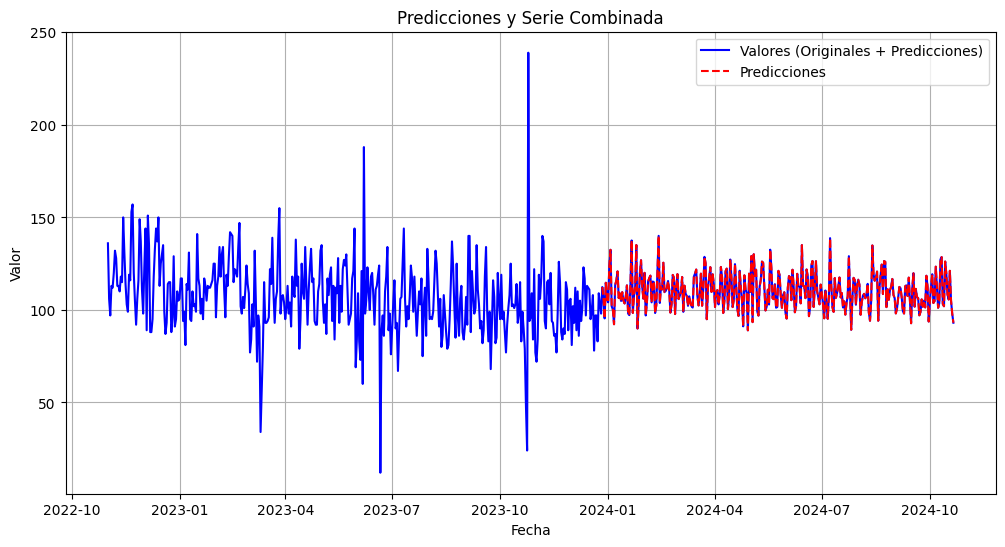

In [ ]:
from datetime import timedelta

# Reemplaza `original_values` y `original_dates` con los valores reales de tu serie
original_values = scaler_inverse.inverse_transform(y_test.reshape(-1, 1)).flatten()  # Últimos valores reales
original_dates = pd.date_range(start="2022-11-01", periods=len(original_values), freq="D")  # Fechas originales

# Parámetros para las predicciones
start_date_predictions = original_dates[-1] + timedelta(days=1)  # La primera fecha de las predicciones
freq = "D"  # Frecuencia diaria
future_steps = len(predicted_future_values)  # Longitud de las predicciones

# Crear el rango de fechas para las predicciones
prediction_dates = pd.date_range(start=start_date_predictions, periods=future_steps, freq=freq)

# Versión 1: DataFrame solo con predicciones
df_predictions = pd.DataFrame({
    "Fecha": prediction_dates,
    "Valores_Predichos": predicted_future_values
})

# Versión 2: Combinar los últimos valores originales con las predicciones
all_dates = np.concatenate((original_dates, prediction_dates))
all_values = np.concatenate((original_values, predicted_future_values))

df_combined = pd.DataFrame({
    "Fecha": all_dates,
    "Valores": all_values
})



# Graficar ambas versiones
plt.figure(figsize=(12, 6))
# Gráfico combinado
plt.plot(df_combined["Fecha"], df_combined["Valores"], label="Valores (Originales + Predicciones)", color="blue")
# Gráfico con predicciones
plt.plot(df_predictions["Fecha"], df_predictions["Valores_Predichos"], label="Predicciones", color="red", linestyle="dashed")
plt.title("Predicciones y Serie Combinada")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.legend()
plt.grid()
plt.show()


In [ ]:
start_date_predictions

Timestamp('2023-12-27 00:00:00')

In [ ]:
# Mostrar los DataFrames
#print("DataFrame con solo predicciones:")
df_predictions.head()

#print("\nDataFrame combinado:")
#df_combined.tail()

,Fecha,Valores_Predichos
0,2023-12-27,112.350716
1,2023-12-28,106.566269
2,2023-12-29,95.410713
3,2023-12-30,114.668098
4,2023-12-31,105.819878


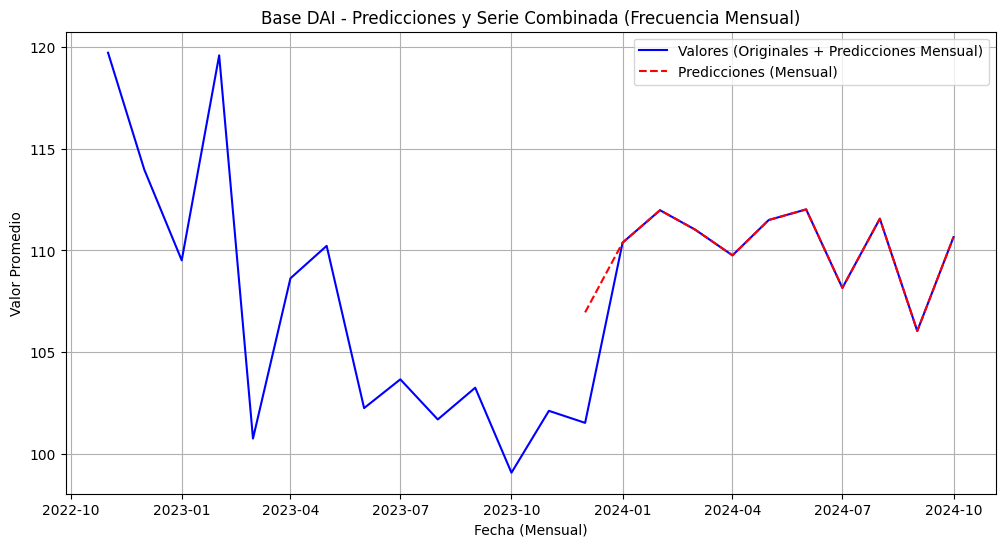

In [ ]:
# Agrupar por mes y calcular el promedio para la versión de predicciones
df_predictions["Fecha_Mes"] = df_predictions["Fecha"].dt.to_period("M")
df_monthly_predictions = df_predictions.groupby("Fecha_Mes")["Valores_Predichos"].mean().reset_index()
df_monthly_predictions["Fecha_Mes"] = df_monthly_predictions["Fecha_Mes"].dt.to_timestamp()

# Agrupar por mes y calcular el promedio para la versión combinada
df_combined["Fecha_Mes"] = df_combined["Fecha"].dt.to_period("M")
df_monthly_combined = df_combined.groupby("Fecha_Mes")["Valores"].mean().reset_index()
df_monthly_combined["Fecha_Mes"] = df_monthly_combined["Fecha_Mes"].dt.to_timestamp()

# Graficar ambas versiones (mensuales)
plt.figure(figsize=(12, 6))

# Gráfico combinado mensual
plt.plot(df_monthly_combined["Fecha_Mes"], df_monthly_combined["Valores"],
         label="Valores (Originales + Predicciones Mensual)", color="blue")

# Gráfico de predicciones mensuales
plt.plot(df_monthly_predictions["Fecha_Mes"], df_monthly_predictions["Valores_Predichos"],
         label="Predicciones (Mensual)", color="red", linestyle="dashed")

# Configuración del gráfico
plt.title("Base DAI - Predicciones y Serie Combinada (Frecuencia Mensual)")
plt.xlabel("Fecha (Mensual)")
plt.ylabel("Valor Promedio")
plt.legend()
plt.grid()
plt.show()


In [ ]:
#ruta_salida = "/content/drive/MyDrive/Taller de Complejidad/bases/"
df_combined.to_csv(f'{ruta_salida}serie_tiempo_C5_month_AB.csv', sep=',', index=False, encoding='utf-8')

In [ ]:
inci2024 = "/content/drive/MyDrive/Taller de Complejidad/bases/BD_2024.csv"

In [ ]:
import dask.dataframe as dd

In [ ]:
df = pd.read_csv(inci2024)

<ipython-input-83-4c471d04dee6>:1: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(inci2024)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 784274 entries, 0 to 784273
Data columns (total 45 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   folio                 784274 non-null  object        
 1   origen_incidente      784274 non-null  object        
 2   fecha_creacion        784274 non-null  object        
 3   hora_creacion         784274 non-null  object        
 4   fecha_cierre          784274 non-null  object        
 5   hora_cierre           784274 non-null  object        
 6   usuario_inicia        784274 non-null  object        
 7   existe_video          784274 non-null  object        
 8   numero_llamante       784274 non-null  object        
 9   nombre_llamante       784274 non-null  object        
 10  numero_alternativo    784274 non-null  object        
 11  incidente_c4          784274 non-null  object        
 12  tipo_intervencion_c2  784274 non-null  object        
 13 

In [ ]:
df.head()

,folio,origen_incidente,fecha_creacion,hora_creacion,fecha_cierre,hora_cierre,usuario_inicia,existe_video,numero_llamante,nombre_llamante,...,t_aten_066,t_desp_c2_c4,t_unidad,t_total,fecha_delito,month,month_char,year,day,dia_char
0,C2C/20240101/00034,BOTÓN DE AUXILIO,01/01/2024,2:08:55,01/01/2024,5:12:44,EXTERNO,-,2320,-,...,-,0:06:37,0:05:00,0:24:26,NaT,NaN,NaN,NaN,NaN,NaN
1,C5/20240101/00652,LLAMADA DEL 911,01/01/2024,1:54:54,01/01/2024,5:03:29,C51098740,-,5582523760,CAROL ARANZA BEDOLLA RENDON,...,-,0:06:38,0:00:11,0:08:14,NaT,NaN,NaN,NaN,NaN,NaN
2,C5/20231231/04325,LLAMADA DEL 911,31/12/2023,21:33:19,01/01/2024,0:43:28,C51111352,-,5531931926,-,...,-,0:00:27,0:00:26,0:01:57,NaT,NaN,NaN,NaN,NaN,NaN
3,C5/20231231/04333,LLAMADA DEL 911,31/12/2023,21:35:46,01/01/2024,2:05:25,C51110093,-,5579949701,VIANEY SALDIVAR SALDIVAR TRUJILLO,...,-,4:27:54,0:00:02,4:29:14,NaT,NaN,NaN,NaN,NaN,NaN
4,C5/20231231/04336,LLAMADA DEL 911,31/12/2023,21:36:35,01/01/2024,0:33:49,C51111352,-,5569155214,JAUN CARLOS MARTINEZ ORTEGA,...,-,0:17:19,0:03:12,0:21:21,NaT,NaN,NaN,NaN,NaN,NaN


# Graficar serie de tiempo

In [ ]:
#columna c5 'fecha_creacion', fiscalia: fecha_inicio  notas: standard_date

df['fecha_delito'] = pd.to_datetime(df['fecha_cierre'], format='%Y-%m-%d', errors='coerce')

# Crear las nuevas columnas para mes, año, día y sus versiones en texto
df['month'] = df['fecha_delito'].dt.month                      # Mes como número (ej: 1 para enero)
df['month_char'] = df['fecha_delito'].dt.month_name()          # Mes como texto (ej: "January")
df['year'] = df['fecha_delito'].dt.year                        # Año (ej: 2024)
df['day'] = df['fecha_delito'].dt.day                          # Día como número (ej: 15)
df['dia_char'] = df['fecha_delito'].dt.day_name()              # Día como texto (ej: "Monday")

# Para nombres de meses y días en español (si necesario):
df['month_char'] = df['fecha_delito'].dt.strftime('%B')        # Mes como texto en español (ej: "enero")
df['dia_char'] = df['fecha_delito'].dt.strftime('%A')          # Día como texto en español (ej: "lunes")


In [ ]:
# Agrupar los datos por fecha y contar el número de delitos por dia
serie_tiempo_2024 = df.groupby(df['fecha_cierre'].dt.to_period('D')).size()
#serie_tiempo_2024 = df.groupby(df['fecha_delito'].dt.to_period('M')).size()
print(len(serie_tiempo_2024))

AttributeError: Can only use .dt accessor with datetimelike values

# <font color="#00FFFF">Correlaciones entre las series temporales</font>

In [ ]:
df = pd.read_csv(f'{ruta_salida}serie_tiempo_C5_mensual_AB.csv')
#df2 = pd.read_csv(f'{ruta_salida}serie_tiempo_fiscalia_mensual_AB.csv')
#df3 = pd.read_csv(f'{ruta_salida}serie_tiempo_FSICALIA_RANDOM_FOREST_AB.csv')

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Taller de Complejidad/Perimetro A-B/output/serie_tiempo_C5_mensual_AB.csv'

In [ ]:
len(df3)
df3.head()

,anio,mes,conteo,mes_anio
0,2018,1,6431,2018-01
1,2018,2,6607,2018-02
2,2018,3,8353,2018-03
3,2018,4,7518,2018-04
4,2018,5,7749,2018-05


In [ ]:
df['num_delitos_forest'] = df3['conteo']
df['num_delitos_fis'] = df2['num_delitos']

In [ ]:
df.head()

,fecha_delito,num_delitos,_num_delitos_forest,num_delitos_forest,num_delitos_fis
0,2018-01-01,9406,6431,6431,5559
1,2018-02-01,9501,6607,6607,5158
2,2018-03-01,11617,8353,8353,5672
3,2018-04-01,10497,7518,7518,5549
4,2018-05-01,10977,7749,7749,5772


In [ ]:
#df.drop(columns=['Fecha'], inplace=True)
df.drop(columns=['fecha_delito'], inplace=True)

In [ ]:
df.head()

,num_delitos,num_delitos_forest,num_delitos_fis
0,9406,6431,5559
1,9501,6607,5158
2,11617,8353,5672
3,10497,7518,5549
4,10977,7749,5772


In [ ]:
corr_matrix = df.corr()
print("Correlation matrix:")
print(corr_matrix)

Correlation matrix:
                    num_delitos  num_delitos_forest  num_delitos_fis
num_delitos            1.000000            0.993136        -0.422815
num_delitos_forest     0.993136            1.000000        -0.515372
num_delitos_fis       -0.422815           -0.515372         1.000000


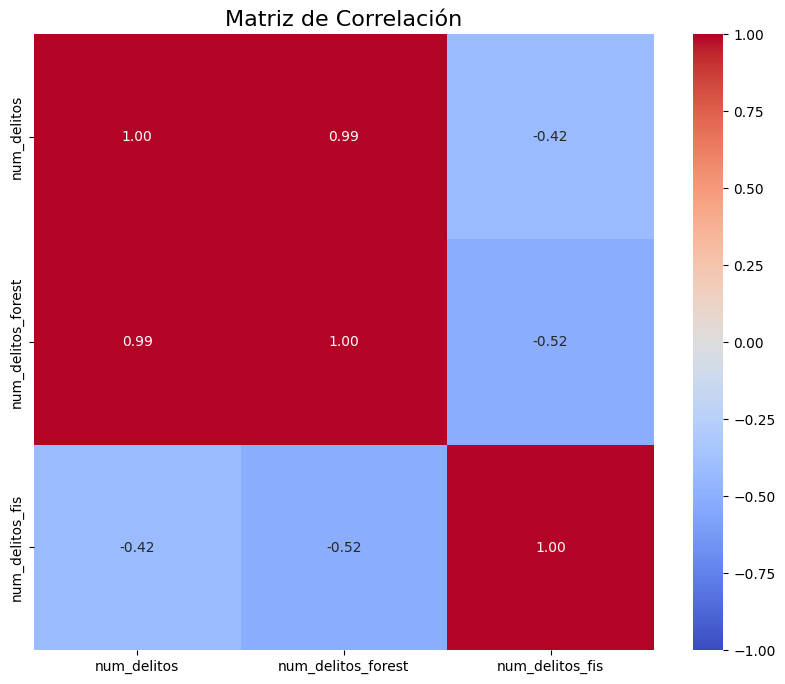

Matriz de correlación exportada a 'matriz_correlacion.csv'.


In [ ]:
# Calcular la matriz de correlación
corr_matrix = df.corr()

# Crear un heatmap para visualizar la matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,        # Mostrar valores numéricos dentro de las celdas
    fmt=".2f",         # Formato numérico con dos decimales
    cmap="coolwarm",   # Escala de colores para resaltar correlaciones positivas y negativas
    vmin=-1, vmax=1    # Límite del rango de correlación
)
plt.title("Matriz de Correlación", fontsize=16)
plt.show()

# Exportar la matriz de correlación como tabla para un informe
corr_matrix.to_csv("matriz_correlacion.csv", index=True)
print("Matriz de correlación exportada a 'matriz_correlacion.csv'.")


# Correlaciones predicciones

In [ ]:
df = pd.read_csv(f'{ruta_salida}serie_tiempo_C5_valores_predichos_desnormalizados.csv')
df2 = pd.read_csv(f'{ruta_salida}serie_tiempo_fiscalia_valores_predichos_desnormalizados.csv')
df3=df

In [ ]:
df3['Valores_Predichos_c5'] = df['Valores_Predichos_Desnormalizados']
df3['Valores_Predichos_Fiscalia'] = df2['Valores_Predichos_Desnormalizados']


In [ ]:
df3.head()

,Valores_Predichos_c5,Valores_Predichos_Fiscalia
0,1131.34700,96.534010
1,875.11040,89.629906
2,431.92273,99.083466
3,305.93268,87.769264
4,328.81757,83.409110


In [ ]:
#df.drop(columns=['Fecha'], inplace=True)
#df3.drop(columns=["Fecha","Valores_Predichos_Desnormalizados"], inplace=True)

df=df3

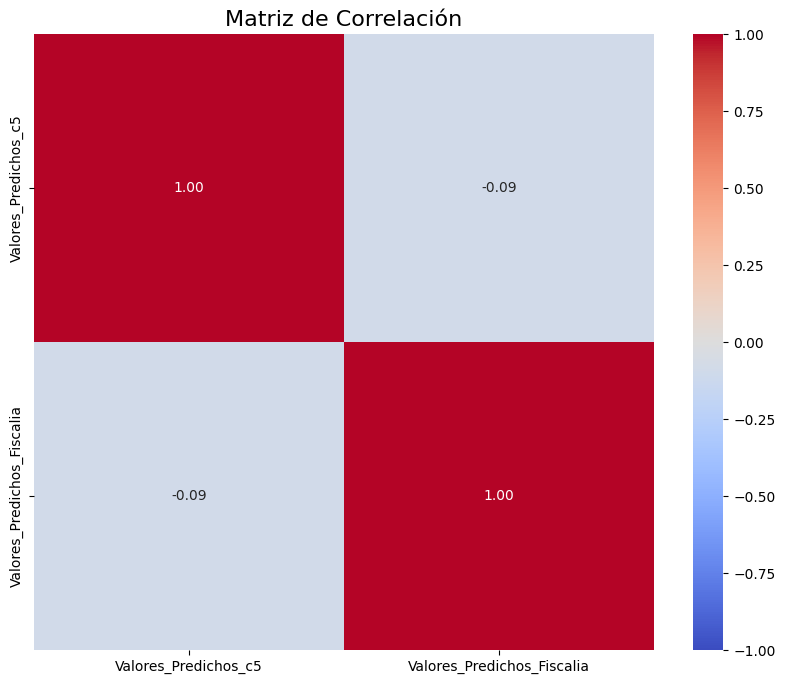

Matriz de correlación exportada a 'matriz_correlacion.csv'.


In [ ]:
# Calcular la matriz de correlación
corr_matrix = df.corr()

# Crear un heatmap para visualizar la matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,        # Mostrar valores numéricos dentro de las celdas
    fmt=".2f",         # Formato numérico con dos decimales
    cmap="coolwarm",   # Escala de colores para resaltar correlaciones positivas y negativas
    vmin=-1, vmax=1    # Límite del rango de correlación
)
plt.title("Matriz de Correlación", fontsize=16)
plt.show()

# Exportar la matriz de correlación como tabla para un informe
corr_matrix.to_csv("matriz_correlacion.csv", index=True)
print("Matriz de correlación exportada a 'matriz_correlacion.csv'.")